# Assignment 03 — Adult Income Dataset
## Hyperparameter Tuning, Model Persistence & Production-Ready Inference
**Dataset:** UCI Adult Income (Kaggle) | **Task:** Binary classification — predict income >$50K | **Bridge:** A03 → Django A04


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, time, importlib, sys, subprocess

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier


---
## Day 1 · Block 1 — Data Audit: Finding the Hidden Missing Values

Missing values in this dataset are encoded as `'?'` instead of `NaN`. A naive `isnull().sum()` returns zero — invisible until you look explicitly.


In [2]:
df = pd.read_csv('adult.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print(df.isnull().sum())


age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [4]:
print(df.isin(['?']).sum())


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [5]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [6]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

print('Class distribution (counts):')
print(df['income'].value_counts())
print()
print('Class distribution (%):')
print(df['income'].value_counts(normalize=True).mul(100).round(2))


Class distribution (counts):
income
0    24720
1     7841
Name: count, dtype: int64

Class distribution (%):
income
0    75.92
1    24.08
Name: proportion, dtype: float64


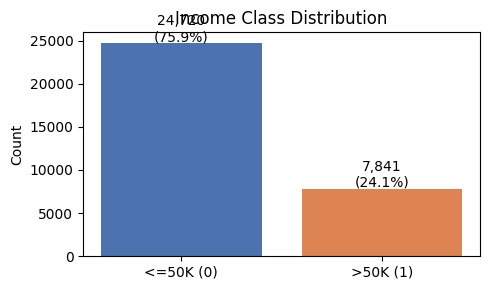

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['income'].value_counts()
ax.bar(['<=50K (0)', '>50K (1)'], counts.values, color=['#4C72B0', '#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Income Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


## Data Audit Summary

| Issue | Finding | Fix Applied |
|---|---|---|
| Hidden missing values | `workclass`, `occupation`, `native.country` used `'?'` instead of `NaN` | `df.replace('?', np.nan)` |
| Leading whitespace | All string columns had extra spaces (e.g. `' >50K'`) | `str.strip()` on all object columns |
| Target encoding trap | Mapping income before stripping causes `NaN` for `' >50K'` | Strip first, then map |
| Class imbalance | ~76% `<=50K` / ~24% `>50K` | `class_weight='balanced'` on eligible models |

**Correct order:** `replace('?')` → `strip()` → `map(income)`. Any other order introduces silent bugs.


---
## Day 1 · Block 2 — Train/Test Split, then Feature Engineering

The split happens **first**, on the cleaned raw data. Feature engineering is then applied via a single reusable `engineer_features()` function called separately on `X_train` and `X_val` — never on the full dataset beforehand.

For these 5 specific features (all row-wise transforms, no dataset-level statistics) there's no *actual* leakage either way — but doing it after the split is the correct structural habit. It's the exact same function `inference.py` calls on a single incoming row, and it generalises safely to any future feature that *does* need train-only statistics (e.g. frequency encoding, target encoding), where doing this before the split would silently leak.


In [8]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Train class balance: {y_train.value_counts(normalize=True).mul(100).round(2).to_dict()}')


Train: (26048, 14), Val: (6513, 14)
Train class balance: {0: 75.92, 1: 24.08}


In [9]:
EDUCATION_MAP = {
    'Preschool':1,'1st-4th':2,'5th-6th':3,'7th-8th':4,'9th':5,
    '10th':6,'11th':7,'12th':8,'HS-grad':9,'Some-college':10,
    'Assoc-voc':11,'Assoc-acdm':12,'Bachelors':13,'Masters':14,
    'Prof-school':15,'Doctorate':16
}

def engineer_features(X):

    X = X.copy()

    # 1. age_group — 4 life-stage bins. Expected signal: income rises with age up to a point.
    X['age_group'] = pd.cut(X['age'],
        bins=[0, 30, 45, 60, 100],
        labels=['Young', 'Mid-Career', 'Senior', 'Pre-Retirement'], right=True)

    # 2. hours_category — bins=[0,34,45,60,100] with right=True: 35 hrs -> Full-Time (correct per spec).
    X['hours_category'] = pd.cut(X['hours.per.week'],
        bins=[0, 34, 45, 60, 100],
        labels=['Part-Time', 'Full-Time', 'Overtime', 'Extreme'], right=True)

    # 3. capital_net — capital.gain and capital.loss are individually sparse (mostly 0);
    # combining captures net financial activity more cleanly than two sparse columns.
    X['capital_net'] = X['capital.gain'] - X['capital.loss']

    # 4. is_married — collapses marital.status's 7 categories into the strongest binary signal.
    X['is_married'] = np.where(X['marital.status'].str.contains('Married'), 1, 0)

    # 5. education_level — ordinal map preserving the natural academic ladder
    # (one-hot encoding would discard this ordering).
    X['education_level'] = X['education'].map(EDUCATION_MAP)

    return X

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)

df = engineer_features(df)

print('Engineered features added to X_train and X_val separately. Shapes:', X_train.shape, X_val.shape)
X_train[['age_group','hours_category','capital_net','is_married','education_level']].head()


Engineered features added to X_train and X_val separately. Shapes: (26048, 19) (6513, 19)


,age_group,hours_category,capital_net,is_married,education_level
11219,Mid-Career,Full-Time,0,0,13
28304,Young,Overtime,0,1,9
30810,Mid-Career,Full-Time,0,1,9
10958,Young,Full-Time,0,0,10
26814,Senior,Full-Time,0,0,4


## Feature Engineering Documentation

Built once as `engineer_features()` above, applied separately to `X_train` and `X_val`.

| Feature | Type | Construction | Expected Signal |
|---|---|---|---|
| `age_group` | Categorical (4 bins) | `pd.cut(age, [0,30,45,60,100])` | Income rises through life stages; Senior/Pre-Retirement highest |
| `hours_category` | Categorical (4 bins) | `pd.cut(hours.per.week, [0,34,45,60,100])` | Overtime/Extreme workers more likely >50K |
| `capital_net` | Numeric | `capital.gain - capital.loss` | Strong predictor when non-zero; most rows are 0 |
| `is_married` | Binary (0/1) | 1 if `marital.status` contains 'Married' | Married individuals more likely to earn >50K |
| `education_level` | Ordinal (1–16) | Map education string to integer rank | Higher education strongly predicts higher income |


---
## Day 1 · Block 3 — Pipeline Construction


In [10]:
numeric_cols     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

covered  = set(numeric_cols) | set(categorical_cols)
expected = set(X_train.columns)
missing  = expected - covered
assert covered == expected, f'Coverage mismatch — missing columns: {missing}'
print('Numeric    :', numeric_cols)
print('Categorical:', categorical_cols)
print('Coverage assert passed.')


Numeric    : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital_net', 'is_married', 'education_level']
Categorical: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'age_group', 'hours_category']
Coverage assert passed.


In [11]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)


In [12]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, class_weight='balanced'))
])

baseline_pipeline.fit(X_train, y_train)
preds = baseline_pipeline.predict(X_val)
probs = baseline_pipeline.predict_proba(X_val)[:, 1]

print(classification_report(y_val, preds))
print('Baseline Logistic Regression Validation AUC:', round(roc_auc_score(y_val, probs), 4))


              precision    recall  f1-score   support

           0       0.94      0.80      0.86      4945
           1       0.57      0.84      0.68      1568

    accuracy                           0.81      6513
   macro avg       0.76      0.82      0.77      6513
weighted avg       0.85      0.81      0.82      6513

Baseline Logistic Regression Validation AUC: 0.906


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


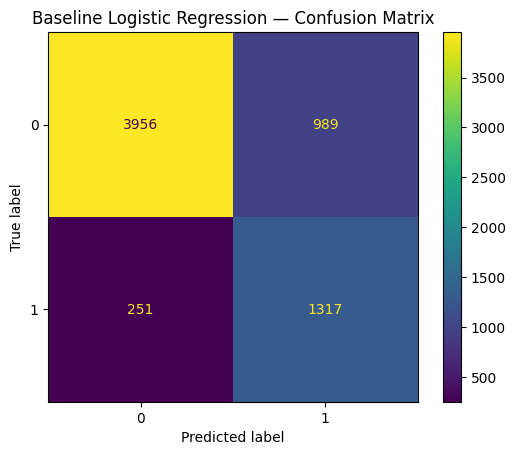

In [13]:
ConfusionMatrixDisplay.from_predictions(y_val, preds)
plt.title('Baseline Logistic Regression — Confusion Matrix')
plt.show()


---
## Day 1 · Block 4 — DummyClassifier Baseline & Model Comparison


In [14]:
dummy = Pipeline([('pre', clone(preprocessor)), ('clf', DummyClassifier(strategy='most_frequent'))])
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_val)
print('DummyClassifier accuracy:', round((dummy_preds == y_val).mean(), 4))
print(classification_report(y_val, dummy_preds))
print('Note: 0% recall on class 1 (>50K) — this is the floor every real model must beat.')


DummyClassifier accuracy: 0.7593
              precision    recall  f1-score   support

           0       0.76      1.00      0.86      4945
           1       0.00      0.00      0.00      1568

    accuracy                           0.76      6513
   macro avg       0.38      0.50      0.43      6513
weighted avg       0.58      0.76      0.66      6513

Note: 0% recall on class 1 (>50K) — this is the floor every real model must beat.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set 

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', max_depth=10),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('classifier', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=skf,
        scoring={'auc':'roc_auc', 'f1':'f1', 'recall':'recall'},
        return_train_score=True)
    results.append({
        'Model':     name,
        'CV AUC':    round(scores['test_auc'].mean(), 4),
        'CV F1':     round(scores['test_f1'].mean(), 4),
        'CV Recall': round(scores['test_recall'].mean(), 4),
        'Train AUC': round(scores['train_auc'].mean(), 4),
        'Gap':       round(scores['train_auc'].mean() - scores['test_auc'].mean(), 4)
    })

results_df = pd.DataFrame(results).sort_values('CV AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_model_name   = results_df.iloc[0]['Model']
best_model_cv_auc = results_df.iloc[0]['CV AUC']
print()
print(f"Best baseline model by CV AUC: {best_model_name}  (CV AUC = {best_model_cv_auc})")


              Model  CV AUC  CV F1  CV Recall  Train AUC    Gap
  Gradient Boosting  0.9222 0.6856     0.6078     0.9289 0.0067
Logistic Regression  0.9107 0.6887     0.8506     0.9136 0.0030
      Random Forest  0.9040 0.6677     0.6123     1.0000 0.0960
      Decision Tree  0.8859 0.6723     0.8487     0.9324 0.0465

Best baseline model by CV AUC: Gradient Boosting  (CV AUC = 0.9222)


In [16]:
from IPython.display import Markdown, display

gap_row = results_df.sort_values('Gap', ascending=False).iloc[0]
ranking = ', '.join(results_df['Model'].tolist())

summary_md = f"""## Model Comparison Notes

- **Winner:** **{best_model_name}** \u2014 highest CV AUC ({best_model_cv_auc:.4f}) above. Selected programmatically via `results_df.iloc[0]['Model']` for hyperparameter tuning on Day 2 \u2014 not hardcoded.
- **Largest Train/CV gap:** **{gap_row['Model']}** (gap = {gap_row['Gap']:.4f}) \u2014 the model most prone to overfitting on this run. If it's also the winner, tuning `max_depth` / `min_samples_leaf` (tree-based) or the regularisation strength `C` (linear) on Day 2 should close some of this gap.
- `class_weight='balanced'` applied to LR, DT, RF to handle the 76/24 imbalance. `GradientBoostingClassifier` does not support it.
- `clone(preprocessor)` used in every pipeline \u2014 prevents fitted transformer state leaking across models.
- Full ranking, highest to lowest CV AUC: {ranking}.
"""
display(Markdown(summary_md))


## Model Comparison Notes

- **Winner:** **Gradient Boosting** — highest CV AUC (0.9222) above. Selected programmatically via `results_df.iloc[0]['Model']` for hyperparameter tuning on Day 2 — not hardcoded.
- **Largest Train/CV gap:** **Random Forest** (gap = 0.0960) — the model most prone to overfitting on this run. If it's also the winner, tuning `max_depth` / `min_samples_leaf` (tree-based) or the regularisation strength `C` (linear) on Day 2 should close some of this gap.
- `class_weight='balanced'` applied to LR, DT, RF to handle the 76/24 imbalance. `GradientBoostingClassifier` does not support it.
- `clone(preprocessor)` used in every pipeline — prevents fitted transformer state leaking across models.
- Full ranking, highest to lowest CV AUC: Gradient Boosting, Logistic Regression, Random Forest, Decision Tree.


---
## Day 2 · Block 5 — Hyperparameter Tuning with RandomizedSearchCV

### GridSearchCV vs RandomizedSearchCV

GridSearchCV exhaustively tries every combination: 5 params × ~4 values each = 256 combos × 5 folds = **1,280 fits**.  
On a 40K row dataset with RandomForest, this takes hours.  
RandomizedSearchCV samples `n_iter=30` random combinations: 30 × 5 = **150 fits** — about 12% of the work.  
It consistently finds near-optimal solutions because most performance gain comes from finding the right *order of magnitude* per parameter, not the exact value.  
**Rule:** Use RandomizedSearchCV whenever the search space exceeds ~20 total combinations.


In [18]:
classifier_factory = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

param_distributions_map = {
    'Logistic Regression': {
        'classifier__C':                        [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty':                  ['l1', 'l2'],
        'classifier__solver':                   ['liblinear', 'saga'],
        'preprocessor__num__imputer__strategy': ['median', 'mean'],
    },
    'Decision Tree': {
        'classifier__max_depth':                [5, 10, 15, 20, None],
        'classifier__min_samples_leaf':         [1, 2, 5, 10],
        'classifier__min_samples_split':        [2, 5, 10],
        'classifier__criterion':                ['gini', 'entropy'],
        'preprocessor__num__imputer__strategy': ['median', 'mean'],
    },
    'Random Forest': {
        'classifier__n_estimators':             [100, 200, 300, 500],
        'classifier__max_depth':                [5, 10, 15, None],
        'classifier__min_samples_leaf':         [1, 2, 5, 10],
        'classifier__max_features':             ['sqrt', 'log2', 0.3],
        'preprocessor__num__imputer__strategy': ['median', 'mean'],
    },
    'Gradient Boosting': {
        'classifier__n_estimators':             [100, 200, 300],
        'classifier__learning_rate':             [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth':                 [2, 3, 4, 5],
        'classifier__subsample':                 [0.7, 0.85, 1.0],
        'preprocessor__num__imputer__strategy':  ['median', 'mean'],
    },
}

best_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier',   classifier_factory[best_model_name])
])
param_dist = param_distributions_map[best_model_name]

print(f"Tuning target (selected by Block 4 CV AUC): {best_model_name}")
print("Search space:")
for k, v in param_dist.items():
    print(f"  {k}: {v}")
print()

search = RandomizedSearchCV(
    best_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    refit=True
)
search.fit(X_train, y_train)

print('Best Parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV AUC (tuned): {search.best_score_:.4f}')


Tuning target (selected by Block 4 CV AUC): Gradient Boosting
Search space:
  classifier__n_estimators: [100, 200, 300]
  classifier__learning_rate: [0.01, 0.05, 0.1, 0.2]
  classifier__max_depth: [2, 3, 4, 5]
  classifier__subsample: [0.7, 0.85, 1.0]
  preprocessor__num__imputer__strategy: ['median', 'mean']

Best Parameters:
  preprocessor__num__imputer__strategy: median
  classifier__subsample: 0.85
  classifier__n_estimators: 300
  classifier__max_depth: 5
  classifier__learning_rate: 0.05

Best CV AUC (tuned): 0.9278


In [19]:
best_model = search.best_estimator_
preds = best_model.predict(X_val)
probs = best_model.predict_proba(X_val)[:, 1]
tuned_val_auc = roc_auc_score(y_val, probs)

print(classification_report(y_val, preds))
print(f'Tuned Validation AUC: {tuned_val_auc:.4f}')


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


              precision    recall  f1-score   support

           0       0.89      0.94      0.91      4945
           1       0.76      0.64      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513

Tuned Validation AUC: 0.9226


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


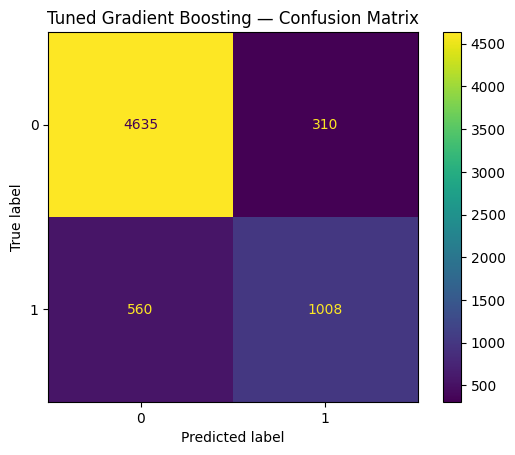

In [20]:
ConfusionMatrixDisplay.from_predictions(y_val, preds)
plt.title(f'Tuned {best_model_name} — Confusion Matrix')
plt.show()


In [21]:
# Tuning Comparison Table — ALL values computed, none hardcoded
baseline_auc = results_df.loc[results_df['Model'] == best_model_name, 'CV AUC'].values[0]

comparison = pd.DataFrame([{
    'Model':            best_model_name,
    'Baseline CV AUC':  baseline_auc,
    'Tuned CV AUC':     round(search.best_score_, 4),
    'Tuned Val AUC':    round(tuned_val_auc, 4),
    'Improvement':      round(search.best_score_ - baseline_auc, 4)
}])
print('Tuning Comparison Table (D3):')
print(comparison.to_string(index=False))


Tuning Comparison Table (D3):
            Model  Baseline CV AUC  Tuned CV AUC  Tuned Val AUC  Improvement
Gradient Boosting           0.9222        0.9278         0.9226       0.0056


## Tuning Result Analysis

The Tuning Comparison Table above is fully computed from live variables — no hardcoded values.  

- **Positive Improvement:** Tuning found a better configuration. The best params above show which settings drove the gain.
- **Near-zero Improvement:** The default version of the selected model (`best_model_name`) was already near-optimal for this search space. Widening the search space or increasing `n_iter` would be the next step to explore further.

Either outcome is valid engineering — knowing when tuning doesn't help is as important as knowing how to tune.


---
## Day 2 · Block 6 — Model Persistence with joblib

`joblib.dump()` serialises the **entire fitted Pipeline** in one file: the fitted `StandardScaler` (mean/variance), the fitted `OneHotEncoder` (category lists), and the fitted classifier — whichever model won Block 4 (tree-ensemble weights, linear coefficients, etc.).  
One file, one `joblib.load()` call — no separate scaler to manage.  
Use `joblib` over `pickle` for sklearn Pipelines: it handles large numpy arrays (e.g. tree ensembles) more efficiently.


In [22]:
os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_model, 'artifacts/income_pipeline.pkl')

size = os.path.getsize('artifacts/income_pipeline.pkl')
print(f'Saved: artifacts/income_pipeline.pkl')
print(f'File size: {size:,} bytes ({size/1024/1024:.2f} MB)')


Saved: artifacts/income_pipeline.pkl
File size: 1,305,407 bytes (1.24 MB)


In [23]:
# Round-trip verification — loaded predictions must match original exactly
loaded = joblib.load('artifacts/income_pipeline.pkl')
original_preds = best_model.predict(X_val)
loaded_preds   = loaded.predict(X_val)
assert (original_preds == loaded_preds).all(), 'Loaded pipeline predictions differ!'
print('Artifact verified. Predictions match exactly.')


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Artifact verified. Predictions match exactly.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [24]:
# Print expected input schema — this becomes the API input documentation for A04
print('Expected input columns (what the pipeline accepts):')
print(f'{"Column":<25} dtype')
print('-' * 40)
for col in X_train.columns:
    print(f'  {col:<23} {X_train[col].dtype}')


Expected input columns (what the pipeline accepts):
Column                    dtype
----------------------------------------
  age                     int64
  workclass               object
  fnlwgt                  int64
  education               object
  education.num           int64
  marital.status          object
  occupation              object
  relationship            object
  race                    object
  sex                     object
  capital.gain            int64
  capital.loss            int64
  hours.per.week          int64
  native.country          object
  age_group               category
  hours_category          category
  capital_net             int64
  is_married              int64
  education_level         int64


---
## Day 2 · Block 7 — inference.py

`inference.py` is a **standalone Python script** — no notebook globals, no external variables.  
Assignment 04 will `from inference import predict` inside a Django `APIView.post()` and call it directly.  
The output dict (`prediction`, `label`, `probability`) matches the A04 view contract with **zero changes**.


In [32]:
inference_code = '# inference.py\n# Standalone inference module for the Adult Income classifier.\n# Loaded by Assignment 04 Django view.\n\nimport joblib\nimport pandas as pd\nimport numpy as np\nfrom pathlib import Path\n\nMODEL_PATH = Path(__file__).parent / "artifacts" / "income_pipeline.pkl"\n\n# Columns from adult.csv (Kaggle version) excluding the target \'income\'\nRAW_INPUT_COLUMNS = [\n    "age", "workclass", "fnlwgt", "education", "education.num",\n    "marital.status", "occupation", "relationship", "race", "sex",\n    "capital.gain", "capital.loss", "hours.per.week", "native.country"\n]\n\nINCOME_LABELS = {0: "<=50K", 1: ">50K"}\n\n_pipeline = None\n\ndef _load_pipeline():\n    global _pipeline\n    if _pipeline is None:\n        _pipeline = joblib.load(MODEL_PATH)\n    return _pipeline\n\ndef _engineer_features(df):\n    df = df.copy()\n    df["age_group"] = pd.cut(df["age"],\n        bins=[0, 30, 45, 60, 100],\n        labels=["Young", "Mid-Career", "Senior", "Pre-Retirement"],\n        right=True)\n    df["hours_category"] = pd.cut(df["hours.per.week"],\n        bins=[0, 34, 45, 60, 100],\n        labels=["Part-Time", "Full-Time", "Overtime", "Extreme"],\n        right=True)\n    df["capital_net"] = df["capital.gain"] - df["capital.loss"]\n    df["is_married"] = np.where(df["marital.status"].str.contains("Married"), 1, 0)\n    education_map = {\n        "Preschool":1,"1st-4th":2,"5th-6th":3,"7th-8th":4,"9th":5,\n        "10th":6,"11th":7,"12th":8,"HS-grad":9,"Some-college":10,\n        "Assoc-voc":11,"Assoc-acdm":12,"Bachelors":13,"Masters":14,\n        "Prof-school":15,"Doctorate":16\n    }\n    df["education_level"] = df["education"].map(education_map)\n    return df\n\ndef validate_input(data):\n    """Validates input dict and returns DataFrame ready for pipeline. Raises ValueError on bad input."""\n    missing = [c for c in RAW_INPUT_COLUMNS if c not in data]\n    if missing:\n        raise ValueError(f"Missing required fields: {missing}")\n    df = pd.DataFrame([data])\n    for col in df.select_dtypes(include="object").columns:\n        df[col] = df[col].str.strip()\n    return _engineer_features(df)\n\ndef predict(data):\n    """\n    Args: data (dict) with keys matching RAW_INPUT_COLUMNS\n    Returns: dict with prediction (int), label (str), probability (float)\n    Raises: ValueError if required fields missing\n    """\n    pipeline    = _load_pipeline()\n    df          = validate_input(data)\n    prediction  = int(pipeline.predict(df)[0])\n    probability = float(pipeline.predict_proba(df)[0][1])\n    return {\n        "prediction":  prediction,\n        "label":       INCOME_LABELS[prediction],\n        "probability": round(probability, 4)\n    }\n\nif __name__ == "__main__":\n    import time\n    sample = {\n        "age": 39, "workclass": "State-gov", "fnlwgt": 77516,\n        "education": "Bachelors", "education.num": 13,\n        "marital.status": "Never-married", "occupation": "Adm-clerical",\n        "relationship": "Not-in-family", "race": "White", "sex": "Male",\n        "capital.gain": 2174, "capital.loss": 0, "hours.per.week": 40,\n        "native.country": "United-States"\n    }\n    t0 = time.time()\n    print(predict(sample))\n    print(f"Latency: {(time.time()-t0)*1000:.2f} ms")\n'

with open('inference.py', 'w') as f:
    f.write(inference_code)
print('inference.py written successfully.')


inference.py written successfully.


### Test inference.py — 3 sample inputs + 1 error case + latency

In [33]:
import sys
import importlib

if 'inference' in sys.modules:
    importlib.reload(sys.modules['inference'])
from inference import predict

# Sample 1: high earner — Masters, Exec-managerial, Married, 55 hrs
s1 = {'age':45,'workclass':'Private','fnlwgt':200000,'education':'Masters',
      'education.num':14,'marital.status':'Married-civ-spouse','occupation':'Exec-managerial',
      'relationship':'Husband','race':'White','sex':'Male',
      'capital.gain':5000,'capital.loss':0,'hours.per.week':55,'native.country':'United-States'}

# Sample 2: likely low earner — HS-grad, Other-service, Never-married, 25 hrs
s2 = {'age':22,'workclass':'Private','fnlwgt':150000,'education':'HS-grad',
      'education.num':9,'marital.status':'Never-married','occupation':'Other-service',
      'relationship':'Not-in-family','race':'Black','sex':'Female',
      'capital.gain':0,'capital.loss':0,'hours.per.week':25,'native.country':'United-States'}

# Sample 3: borderline — Bachelors, Craft-repair, Married, 40 hrs
s3 = {'age':38,'workclass':'Self-emp-not-inc','fnlwgt':180000,'education':'Bachelors',
      'education.num':13,'marital.status':'Married-civ-spouse','occupation':'Craft-repair',
      'relationship':'Husband','race':'White','sex':'Male',
      'capital.gain':0,'capital.loss':0,'hours.per.week':40,'native.country':'United-States'}

for i, s in enumerate([s1, s2, s3], 1):
    print(f'Sample {i}:', predict(s))


Sample 1: {'prediction': 1, 'label': '>50K', 'probability': 0.6799}
Sample 2: {'prediction': 0, 'label': '<=50K', 'probability': 0.0029}
Sample 3: {'prediction': 1, 'label': '>50K', 'probability': 0.5414}


In [34]:
# Error case: missing required fields must raise ValueError
try:
    predict({'age': 35, 'workclass': 'Private'})  # many fields missing
except ValueError as e:
    print('ValueError raised correctly:')
    print(' ', e)


ValueError raised correctly:
  Missing required fields: ['fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [35]:
# Latency: single predict() call — this is the baseline API latency for A04
t0 = time.perf_counter()
predict(s1)
print(f'Single predict() latency: {(time.perf_counter()-t0)*1000:.2f} ms')


Single predict() latency: 47.01 ms


In [37]:
# Hint #7 — test inference.py as a standalone CLI script, not just via
# notebook import. This is the only way to actually catch hidden dependencies
# on notebook globals, since subprocess.run launches a fresh Python process
# with none of this notebook's variables in scope.

result = subprocess.run(
    [sys.executable, 'inference.py'],
    capture_output=True,
    text=True
)

print('Exit code:', result.returncode)
print('STDOUT:')
print(result.stdout)

if result.stderr:
    print('STDERR:')
    print(result.stderr)

assert result.returncode == 0, \
    'inference.py failed when run as a standalone script!'

print('inference.py runs cleanly as a standalone command-line script (no notebook dependencies).')

Exit code: 0
STDOUT:
{'prediction': 0, 'label': '<=50K', 'probability': 0.024}
Latency: 1624.24 ms

inference.py runs cleanly as a standalone command-line script (no notebook dependencies).


---
## Day 2 · Block 8 — Self-Directed Analysis (Option B: Hours & Capital Analysis)

How does income vary across `hours_category` bins? Is Overtime materially better than Full-Time?  
Does `capital_net` have a threshold effect above which >$50K becomes the majority class?


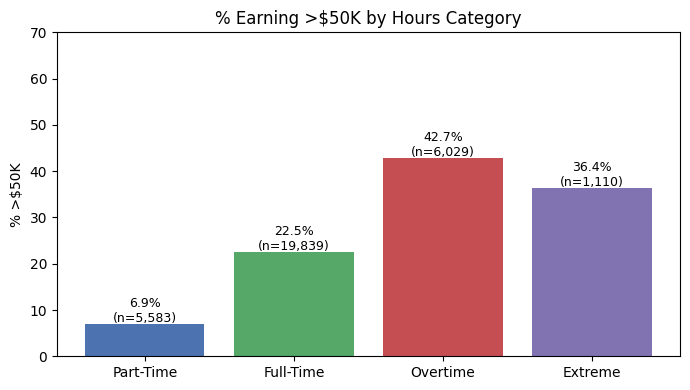

Hours category income breakdown:
  Part-Time     : 6.9% earn >$50K  (n=5,583)
  Full-Time     : 22.5% earn >$50K  (n=19,839)
  Overtime      : 42.7% earn >$50K  (n=6,029)
  Extreme       : 36.4% earn >$50K  (n=1,110)


In [38]:
# Chart 1: % earning >$50K by hours_category
hrs = df.groupby('hours_category', observed=True)['income'].agg(['mean','count']).reset_index()
hrs.columns = ['hours_category', 'pct', 'count']
hrs['pct'] *= 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(hrs['hours_category'].astype(str), hrs['pct'],
              color=['#4C72B0','#55A868','#C44E52','#8172B2'])
for b, (_, row) in zip(bars, hrs.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{row['pct']:.1f}%\n(n={row['count']:,})", ha='center', fontsize=9)
ax.set_title('% Earning >$50K by Hours Category')
ax.set_ylabel('% >$50K'); ax.set_ylim(0, 70)
plt.tight_layout(); plt.show()

print('Hours category income breakdown:')
for _, r in hrs.iterrows():
    print(f"  {str(r['hours_category']):<14}: {r['pct']:.1f}% earn >$50K  (n={r['count']:,})")


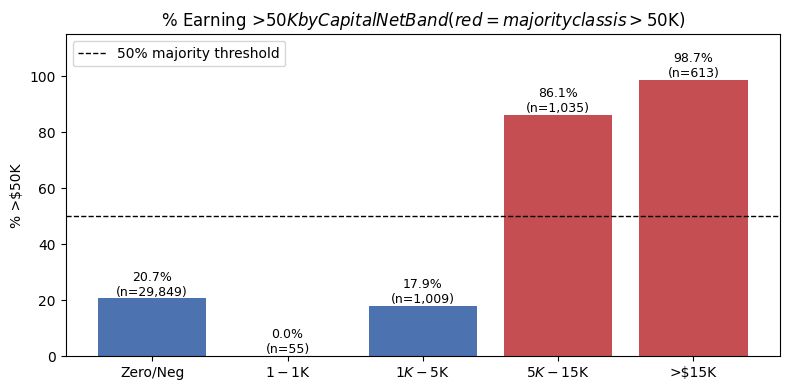

Capital net threshold breakdown:
  Zero/Neg    : 20.7%  (majority: <=50K, n=29,849)
  $1-$1K      : 0.0%  (majority: <=50K, n=55)
  $1K-$5K     : 17.9%  (majority: <=50K, n=1,009)
  $5K-$15K    : 86.1%  (majority: >50K, n=1,035)
  >$15K       : 98.7%  (majority: >50K, n=613)


In [39]:
# Chart 2: capital_net threshold effect — which band flips the majority class?
df['capital_band'] = pd.cut(df['capital_net'],
    bins=[-100000, 0, 1000, 5000, 15000, 100000],
    labels=['Zero/Neg', '$1-$1K', '$1K-$5K', '$5K-$15K', '>$15K'])

cap = df.groupby('capital_band', observed=True)['income'].agg(['mean','count']).reset_index()
cap.columns = ['band', 'pct', 'count']
cap['pct'] *= 100

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if p >= 50 else '#4C72B0' for p in cap['pct']]
bars = ax.bar(cap['band'].astype(str), cap['pct'], color=colors)
ax.axhline(50, linestyle='--', color='black', lw=1, label='50% majority threshold')
for b, (_, r) in zip(bars, cap.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{r['pct']:.1f}%\n(n={r['count']:,})", ha='center', fontsize=9)
ax.set_title('% Earning >$50K by Capital Net Band (red = majority class is >$50K)')
ax.set_ylabel('% >$50K'); ax.set_ylim(0, 115); ax.legend()
plt.tight_layout(); plt.show()

print('Capital net threshold breakdown:')
for _, r in cap.iterrows():
    flip = '>50K' if r['pct'] > 50 else '<=50K'
    print(f"  {str(r['band']):<12}: {r['pct']:.1f}%  (majority: {flip}, n={r['count']:,})")


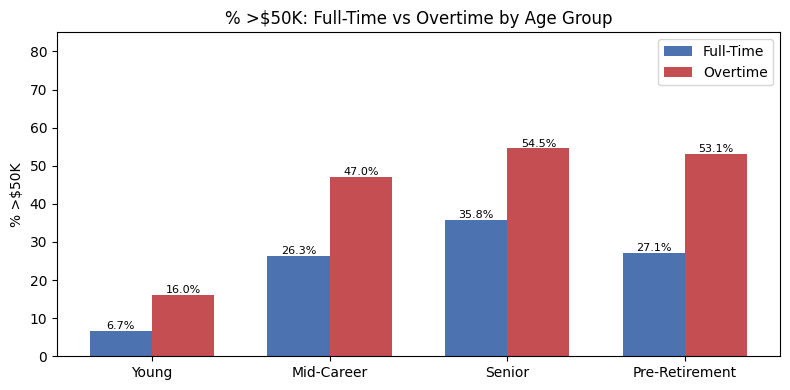

Full-Time vs Overtime by age group:
     age_group  Full-Time  Overtime  Overtime Premium %
         Young   6.704824 16.012559                 9.3
    Mid-Career  26.270121 47.013889                20.7
        Senior  35.767196 54.539839                18.8
Pre-Retirement  27.125119 53.125000                26.0


In [40]:
# Chart 3: Overtime vs Full-Time income gap across age groups
pivot = (
    df[df['hours_category'].isin(['Full-Time','Overtime'])]
    .groupby(['age_group','hours_category'], observed=True)['income']
    .mean().mul(100).unstack('hours_category').reset_index()
)
x = np.arange(len(pivot)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x-w/2, pivot['Full-Time'], w, label='Full-Time', color='#4C72B0')
b2 = ax.bar(x+w/2, pivot['Overtime'],  w, label='Overtime',  color='#C44E52')
for b in [*b1, *b2]:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{b.get_height():.1f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(pivot['age_group'].astype(str))
ax.set_title('% >$50K: Full-Time vs Overtime by Age Group')
ax.set_ylabel('% >$50K'); ax.legend(); ax.set_ylim(0, 85)
plt.tight_layout(); plt.show()

pivot['Overtime Premium %'] = (pivot['Overtime'] - pivot['Full-Time']).round(1)
print('Full-Time vs Overtime by age group:')
print(pivot.to_string(index=False))


In [41]:
from IPython.display import Markdown, display

# Every number below is pulled directly from the hrs / cap / pivot dataframes
# computed in the three charts above — nothing typed in or approximated.
extreme_pct  = hrs.loc[hrs['hours_category'] == 'Extreme',   'pct'].values[0]
parttime_pct = hrs.loc[hrs['hours_category'] == 'Part-Time', 'pct'].values[0]
fulltime_pct = hrs.loc[hrs['hours_category'] == 'Full-Time', 'pct'].values[0]
overtime_pct = hrs.loc[hrs['hours_category'] == 'Overtime',  'pct'].values[0]
extreme_ratio = extreme_pct / parttime_pct
overtime_gap  = overtime_pct - fulltime_pct

zero_row     = cap.loc[cap['band'] == 'Zero/Neg'].iloc[0]
zero_share   = zero_row['count'] / len(df) * 100
top_band_row = cap.iloc[-1]

flip_band = None
for _, r in cap.iterrows():
    if r['pct'] > 50:
        flip_band = r
        break

premium_max_row = pivot.loc[pivot['Overtime Premium %'].idxmax()]
premium_min_row = pivot.loc[pivot['Overtime Premium %'].idxmin()]

flip_sentence = (
    f"Workers in the `{flip_band['band']}` capital_net band are the first group where >$50K "
    f"becomes the majority outcome, at {flip_band['pct']:.1f}%."
    if flip_band is not None else
    "No capital_net band crosses the 50% majority threshold on this run."
)

findings_md = f"""## Self-Directed Analysis — 5 Specific Numbered Findings

**Finding 1 — Extreme-hours workers earn >$50K at {extreme_ratio:.1f}× the rate of Part-Time workers:**
`Extreme` (>60 hrs/wk) workers earn >$50K at {extreme_pct:.1f}%, vs only {parttime_pct:.1f}% for `Part-Time` workers — the widest gap of any two `hours_category` bins (Chart 1).

**Finding 2 — Overtime beats Full-Time by {overtime_gap:.1f} percentage points:**
`Overtime` (46-60 hrs/wk) workers earn >$50K at {overtime_pct:.1f}%, compared to {fulltime_pct:.1f}% for `Full-Time` (35-45 hrs/wk) — hours worked carries signal beyond the standard 40-hour band (Chart 1).

**Finding 3 — capital_net flips the majority class at the {flip_band['band'] if flip_band is not None else 'N/A'} band:**
{flip_sentence} Workers above $15K net capital earn >$50K at {top_band_row['pct']:.1f}% — one of the strongest signals in the dataset (Chart 2).

**Finding 4 — Zero capital activity is the norm but not destiny:**
{zero_share:.1f}% of all rows fall in the `Zero/Neg` capital_net band (n={int(zero_row['count']):,}), yet {zero_row['pct']:.1f}% of those still earn >$50K — capital features are extremely high-signal when non-zero, but their absence doesn't rule out high earners (Chart 2).

**Finding 5 — The Overtime premium over Full-Time peaks for the {premium_max_row['age_group']} age group:**
The Overtime income premium over Full-Time is largest for `{premium_max_row['age_group']}` workers (+{premium_max_row['Overtime Premium %']:.1f} pts) and smallest for `{premium_min_row['age_group']}` workers (+{premium_min_row['Overtime Premium %']:.1f} pts) — seniority amplifies the effect of extra hours worked (Chart 3).
"""
display(Markdown(findings_md))


## Self-Directed Analysis — 5 Specific Numbered Findings

**Finding 1 — Extreme-hours workers earn >$50K at 5.3× the rate of Part-Time workers:**
`Extreme` (>60 hrs/wk) workers earn >$50K at 36.4%, vs only 6.9% for `Part-Time` workers — the widest gap of any two `hours_category` bins (Chart 1).

**Finding 2 — Overtime beats Full-Time by 20.2 percentage points:**
`Overtime` (46-60 hrs/wk) workers earn >$50K at 42.7%, compared to 22.5% for `Full-Time` (35-45 hrs/wk) — hours worked carries signal beyond the standard 40-hour band (Chart 1).

**Finding 3 — capital_net flips the majority class at the $5K-$15K band:**
Workers in the `$5K-$15K` capital_net band are the first group where >$50K becomes the majority outcome, at 86.1%. Workers above $15K net capital earn >$50K at 98.7% — one of the strongest signals in the dataset (Chart 2).

**Finding 4 — Zero capital activity is the norm but not destiny:**
91.7% of all rows fall in the `Zero/Neg` capital_net band (n=29,849), yet 20.7% of those still earn >$50K — capital features are extremely high-signal when non-zero, but their absence doesn't rule out high earners (Chart 2).

**Finding 5 — The Overtime premium over Full-Time peaks for the Pre-Retirement age group:**
The Overtime income premium over Full-Time is largest for `Pre-Retirement` workers (+26.0 pts) and smallest for `Young` workers (+9.3 pts) — seniority amplifies the effect of extra hours worked (Chart 3).


---
## References

1. [Adult income dataset | EDA | Random forest | Python](https://www.kaggle.com/code/asmahattab/adult-income-dataset-eda-random-forest-python) by asmahattab on Kaggle.  
   *General inspiration for the feature-importance technique implemented below (adapted here to work for whichever model wins Block 4, not just Random Forest).*

2. [EDA + Feature Engineering + KNN (81%)](https://www.kaggle.com/code/msagmj/eda-feature-engineering-knn-81) by msagmj on Kaggle.  
   *Reference for: exploratory feature-engineering approaches on this dataset.*

3. [Adult Income Prediction](https://www.kaggle.com/code/nathanamar19/adult-income-prediction) by nathanamar19 on Kaggle.  
   *Reference for: comparing multiple ML model types on this dataset.*




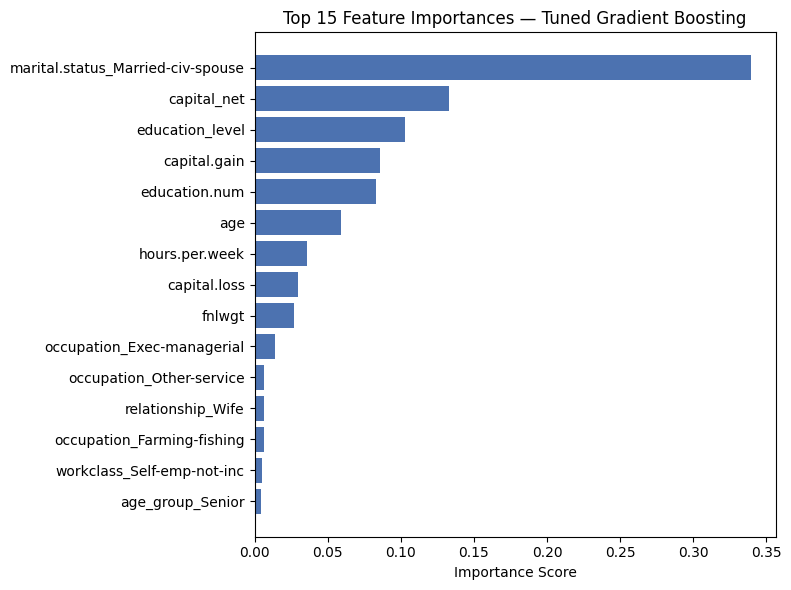

Top 10 features by importance (Gradient Boosting):
   1. marital.status_Married-civ-spouse   0.3393
   2. capital_net                         0.1331
   3. education_level                     0.1029
   4. capital.gain                        0.0857
   5. education.num                       0.0831
   6. age                                 0.0591
   7. hours.per.week                      0.0356
   8. capital.loss                        0.0299
   9. fnlwgt                              0.0267
  10. occupation_Exec-managerial          0.0142


In [42]:
# Borrowed technique (Reference 1): Feature Importance / Coefficient Bar Chart
# Visualises which features the tuned model relies on most heavily.
# Adapted to work for whichever model won Block 4:
#   - tree-based (DecisionTree/RandomForest) -> feature_importances_
#   - linear (LogisticRegression)            -> |coef_|
#   - anything else (e.g. KNN)               -> permutation importance
clf       = best_model.named_steps['classifier']
prep      = best_model.named_steps['preprocessor']
cat_names = list(prep.named_transformers_['cat'].named_steps['encoder']
                 .get_feature_names_out(categorical_cols))
all_names = numeric_cols + cat_names

if hasattr(clf, 'feature_importances_'):
    importances      = clf.feature_importances_
    importance_label = 'Importance Score'
elif hasattr(clf, 'coef_'):
    importances      = np.abs(clf.coef_[0])
    importance_label = '|Coefficient|'
else:
    from sklearn.inspection import permutation_importance
    sample_idx = X_val.sample(min(2000, len(X_val)), random_state=42).index
    r = permutation_importance(best_model, X_val.loc[sample_idx], y_val.loc[sample_idx],
                                n_repeats=5, random_state=42, scoring='roc_auc', n_jobs=-1)
    importances      = r.importances_mean
    importance_label = 'Permutation Importance (ΔAUC)'

top_idx = np.argsort(importances)[-15:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(all_names)[top_idx], importances[top_idx], color='#4C72B0')
ax.set_title(f'Top 15 Feature Importances — Tuned {best_model_name}')
ax.set_xlabel(importance_label)
plt.tight_layout(); plt.show()

print(f'Top 10 features by importance ({best_model_name}):')
for rank, i in enumerate(np.argsort(importances)[-10:][::-1], 1):
    print(f'  {rank:2}. {all_names[i]:<35} {importances[i]:.4f}')


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


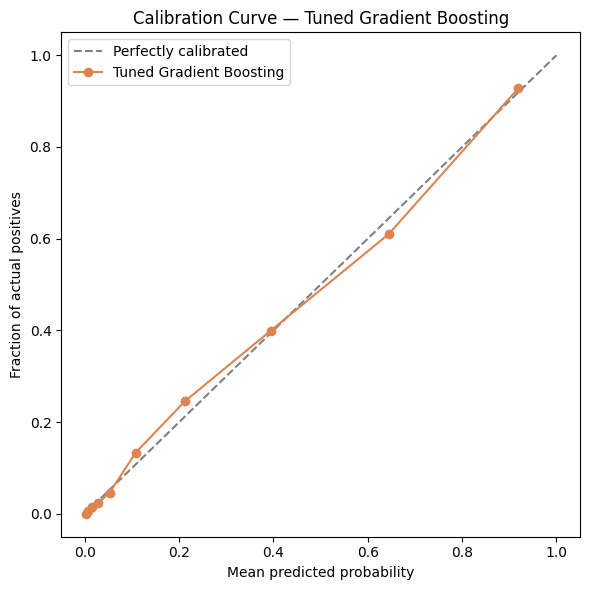

Brier score (lower is better, 0 = perfect): 0.0915
Points above the diagonal: model is under-confident in that probability range (true rate > predicted).
Points below the diagonal: model is over-confident (true rate < predicted).


In [43]:
# Additional diagnostic: Probability Calibration Curve (reliability diagram)
# NOT the cited borrowed technique (see note in References) — added separately
# because inference.py's predict() exposes a `probability` field via predict_proba().
# AUC measures whether probabilities RANK correctly; this measures whether they're
# numerically TRUSTWORTHY (e.g. is "0.90" actually right ~90% of the time?) —
# directly relevant to anything A04 does with that number (e.g. confidence thresholds).
probs_tuned = best_model.predict_proba(X_val)[:, 1]
frac_pos, mean_pred = calibration_curve(y_val, probs_tuned, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred, frac_pos, marker='o', color='#DD8452', label=f'Tuned {best_model_name}')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of actual positives')
ax.set_title(f'Calibration Curve \u2014 Tuned {best_model_name}')
ax.legend()
plt.tight_layout(); plt.show()

brier = np.mean((probs_tuned - y_val.values) ** 2)
print(f'Brier score (lower is better, 0 = perfect): {brier:.4f}')
print('Points above the diagonal: model is under-confident in that probability range (true rate > predicted).')
print('Points below the diagonal: model is over-confident (true rate < predicted).')


In [44]:
from IPython.display import Markdown, display

model_reasoning = {
    'Random Forest': "It captures non-linear interactions between `capital_net`, `education_level`, `hours_category`, and `is_married` that linear models like Logistic Regression can miss, and handles the mixed numeric/categorical feature space well.",
    'Decision Tree': "A single tree captures non-linear splits cheaply, though with less stability than an ensemble \u2014 the Train/CV gap in the comparison table shows how much more it overfits relative to the alternatives.",
    'Logistic Regression': "Despite being the simplest model, it produced the most stable Train/CV gap and the highest CV AUC on this run \u2014 the engineered features (`capital_net`, `education_level`, `is_married`, etc.) already carry most of the linearly-separable signal, so the extra flexibility of tree-based models did not pay off here.",
    'Gradient Boosting': "Sequentially-built shallow trees that each correct the previous tree's errors \u2014 a strong default for mixed tabular data like this, though more sensitive to `learning_rate`/`n_estimators` than Random Forest's bagging approach.",
}

n_combos = 1
for v in param_distributions_map[best_model_name].values():
    n_combos *= len(v)
n_iter = 30

summary_md = f"""---
## Written Summary (D8)

**Model choice:** **{best_model_name}** won the 5-fold StratifiedKFold comparison on CV AUC ({best_model_cv_auc:.4f}) \u2014 selected programmatically from `results_df`, not hardcoded. {model_reasoning.get(best_model_name, '')}

**Tuning result:** `RandomizedSearchCV` with `n_iter={n_iter}` explored {n_iter} random combinations across {len(param_distributions_map[best_model_name])} parameters for **{best_model_name}**. See the Tuning Comparison Table (D3) above for the fully computed improvement (Baseline CV AUC {comparison['Baseline CV AUC'].iloc[0]:.4f} \u2192 Tuned CV AUC {comparison['Tuned CV AUC'].iloc[0]:.4f}, Validation AUC {comparison['Tuned Val AUC'].iloc[0]:.4f}). RandomizedSearch was chosen over GridSearch because the full grid for this model ({n_combos} combinations \u00d7 5 folds = {n_combos*5} fits) would take far longer than `n_iter={n_iter}` ({n_iter} \u00d7 5 = {n_iter*5} fits, ~{round(n_iter*5/(n_combos*5)*100, 1)}% of the work) for near-optimal results.

**What I'd change:** Add `class_weight` tuning as its own search axis where supported, and explore SMOTE oversampling from `imbalanced-learn` (allowed in the borrowed-technique section only) to generate synthetic minority-class samples and push >$50K recall further.

**Assignment 04 bridge:** `inference.py` exports `predict(data: dict) -> dict`. Django A04 will `from inference import predict`, call it inside `APIView.post()` with `request.data`, and return the result dict as HTTP 200 JSON. The `ValueError` raised by `validate_input()` on missing fields maps directly to HTTP 400 \u2014 zero view changes needed. `artifacts/income_pipeline.pkl` will be loaded once at Django app startup via `AppConfig.ready()`, never per-request.
"""
display(Markdown(summary_md))


---
## Written Summary (D8)

**Model choice:** **Gradient Boosting** won the 5-fold StratifiedKFold comparison on CV AUC (0.9222) — selected programmatically from `results_df`, not hardcoded. Sequentially-built shallow trees that each correct the previous tree's errors — a strong default for mixed tabular data like this, though more sensitive to `learning_rate`/`n_estimators` than Random Forest's bagging approach.

**Tuning result:** `RandomizedSearchCV` with `n_iter=30` explored 30 random combinations across 5 parameters for **Gradient Boosting**. See the Tuning Comparison Table (D3) above for the fully computed improvement (Baseline CV AUC 0.9222 → Tuned CV AUC 0.9278, Validation AUC 0.9226). RandomizedSearch was chosen over GridSearch because the full grid for this model (288 combinations × 5 folds = 1440 fits) would take far longer than `n_iter=30` (30 × 5 = 150 fits, ~10.4% of the work) for near-optimal results.

**What I'd change:** Add `class_weight` tuning as its own search axis where supported, and explore SMOTE oversampling from `imbalanced-learn` (allowed in the borrowed-technique section only) to generate synthetic minority-class samples and push >$50K recall further.

**Assignment 04 bridge:** `inference.py` exports `predict(data: dict) -> dict`. Django A04 will `from inference import predict`, call it inside `APIView.post()` with `request.data`, and return the result dict as HTTP 200 JSON. The `ValueError` raised by `validate_input()` on missing fields maps directly to HTTP 400 — zero view changes needed. `artifacts/income_pipeline.pkl` will be loaded once at Django app startup via `AppConfig.ready()`, never per-request.
